<div align="center">

# UNIVERSIDAD PRIVADA ANTENOR ORREGO
### Escuela de Ingeniería de Sistemas e Inteligencia Artificial

**Percepción Computacional (ISIA-111)** <br>
Ms. Armando Caballero Alvarado <br>
Semana 1 — Anatomía del dato sensorial <br>
Semestre: 2026-2

</div>

---

## 1. Preparación del entorno

Antes de tocar cualquier dato necesitamos cargar las herramientas. En percepción computacional trabajamos siempre con la misma estructura de fondo: un arreglo de NumPy. Las demás librerías solo saben leer archivos y convertirlos a ese arreglo, o tomar ese arreglo y dibujarlo.

También definimos aquí la función nota(), que usaremos al final de cada celda para imprimir la interpretación de lo que acabamos de ver. Léela cuando repases: es el resumen de la celda.

In [9]:
import textwrap
import numpy as np                 # arreglos numéricos: la estructura base de todo el curso
import matplotlib.pyplot as plt    # visualización de imágenes y señales
from skimage import data           # imágenes de ejemplo incluidas, sin necesidad de descargar

# %matplotlib inline hace que las figuras se dibujen dentro del notebook
%matplotlib inline

plt.rcParams["figure.figsize"] = (10, 4)   # tamaño por defecto de las figuras

# suppress=True evita la notación científica (1.5e-03) al imprimir arreglos
np.set_printoptions(precision=2, suppress=True)


def nota(texto):
    """Imprime la interpretación del resultado de una celda."""
    print("\n" + "─" * 72)
    print("QUÉ SIGNIFICA ESTE RESULTADO")
    print("─" * 72)
    print(textwrap.dedent(texto).strip())


print("Entorno listo. NumPy versión:", np.__version__)

nota("""
    Esta celda solo carga herramientas, no hay resultado que analizar.
    Retén el rol de cada una: numpy guarda los datos, matplotlib los dibuja,
    skimage nos presta imágenes de ejemplo.
    Si esta celda falla, ninguna de las siguientes funcionará.
""")

Entorno listo. NumPy versión: 2.5.3

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Esta celda solo carga herramientas, no hay resultado que analizar.
Retén el rol de cada una: numpy guarda los datos, matplotlib los dibuja,
skimage nos presta imágenes de ejemplo.
Si esta celda falla, ninguna de las siguientes funcionará.


## 2. Una imagen no es una foto: es una matriz

Tu ojo ve una taza de café. La computadora no ve nada de eso: recibe una tabla de números. En esta celda cargamos una imagen y le preguntamos al objeto qué es, sin dibujarlo todavía.

Los cuatro atributos que vas a consultar aquí (ndim, shape, dtype, rango) son los que usarás durante todo el ciclo para diagnosticar cualquier dato sensorial.

In [10]:
img = data.coffee()      # imagen RGB de ejemplo incluida en scikit-image

# ndim  = número de dimensiones (ejes) del arreglo
# shape = tamaño de cada dimensión, en el orden (alto, ancho, canales)
# dtype = tipo de dato de cada número almacenado
print("Tipo de objeto :", type(img))
print("Dimensiones    :", img.ndim)
print("Forma (H,W,C)  :", img.shape)
print("Tipo de dato   :", img.dtype)
print("Valor mínimo   :", img.min())
print("Valor máximo   :", img.max())

# nbytes = memoria total ocupada, en bytes. Lo dividimos entre 1024 para verlo en KB
print("Memoria (KB)   :", round(img.nbytes / 1024, 1))

nota(f"""
    La imagen es un arreglo de {img.ndim} dimensiones con forma {img.shape}:
    {img.shape[0]} filas (alto), {img.shape[1]} columnas (ancho) y
    {img.shape[2]} canales de color (R, G, B).

    El tipo 'uint8' significa entero sin signo de 8 bits. Con 8 bits se
    pueden representar 2^8 = 256 valores distintos, numerados de 0 a 255.
    Por eso el rango observado es [{img.min()}, {img.max()}] y no [0, 256]:
    el 0 cuenta como el primer valor.

    Ese arreglo tiene {img.size:,} números en total y ocupa
    {img.nbytes/1024:.1f} KB en memoria. Retén esta cifra: en la tarea la
    compararás con lo que pesa el archivo en disco.
""")

Tipo de objeto : <class 'numpy.ndarray'>
Dimensiones    : 3
Forma (H,W,C)  : (400, 600, 3)
Tipo de dato   : uint8
Valor mínimo   : 0
Valor máximo   : 255
Memoria (KB)   : 703.1

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
La imagen es un arreglo de 3 dimensiones con forma (400, 600, 3):
400 filas (alto), 600 columnas (ancho) y
3 canales de color (R, G, B).

El tipo 'uint8' significa entero sin signo de 8 bits. Con 8 bits se
pueden representar 2^8 = 256 valores distintos, numerados de 0 a 255.
Por eso el rango observado es [0, 255] y no [0, 256]:
el 0 cuenta como el primer valor.

Ese arreglo tiene 720,000 números en total y ocupa
703.1 KB en memoria. Retén esta cifra: en la tarea la
compararás con lo que pesa el archivo en disco.


## 3. Mirar los números crudos

Este es el momento más importante de la sesión. Vamos a poner lado a lado lo que tú ves y lo que la computadora tiene: un bloque de 4×4 números.

Presta atención al orden de indexación: img[fila, columna], no img[x, y]. Es la fuente de errores número uno del curso, porque en matemáticas escribimos el punto como (x, y) pero en arreglos la primera posición es la fila, que corresponde a la coordenada vertical.

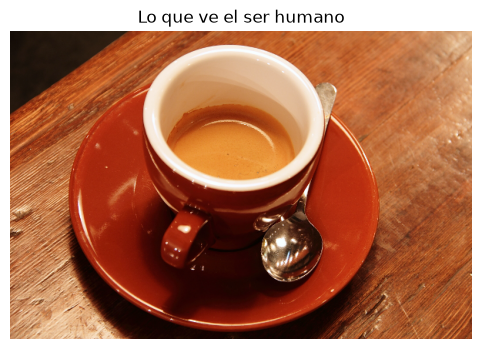

Píxel en la fila 100, columna 150: [180  45  17]
  -> Rojo: 180 | Verde: 45 | Azul: 17

Lo que tiene la computadora en esa zona (canal Rojo, bloque 4x4):
[[180 182 181 178]
 [182 182 178 174]
 [182 177 178 175]
 [178 175 177 175]]

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Arriba viste una taza de café. Abajo está el mismo dato como realmente
se almacena: una tabla de enteros entre 0 y 255.

El píxel consultado vale (np.uint8(180), np.uint8(45), np.uint8(17)). Ese solo píxel es el color que
percibes en ese punto: 180 de rojo, 45 de verde y
17 de azul, mezclados.

En el bloque 4x4 observa que los valores vecinos son PARECIDOS entre sí
(varían en pocas unidades). Esa propiedad se llama correlación espacial
y es la razón por la que las imágenes se pueden comprimir y filtrar.
Si los números fueran aleatorios, no habría nada que percibir.

Recuerda el orden: i

In [11]:
plt.imshow(img)                    # imshow interpreta un arreglo (H,W,3) como imagen RGB
plt.title("Lo que ve el ser humano")
plt.axis("off")
plt.show()

# Indexación: [fila, columna] -> fila 100, columna 150
pixel = img[100, 150]
print("Píxel en la fila 100, columna 150:", pixel)
print("  -> Rojo:", pixel[0], "| Verde:", pixel[1], "| Azul:", pixel[2])

# Slicing: filas 100 a 103, columnas 150 a 153, canal 0 (rojo)
# El límite superior NO se incluye: 100:104 devuelve las filas 100,101,102,103
bloque_r = img[100:104, 150:154, 0]

print("\nLo que tiene la computadora en esa zona (canal Rojo, bloque 4x4):")
print(bloque_r)

nota(f"""
    Arriba viste una taza de café. Abajo está el mismo dato como realmente
    se almacena: una tabla de enteros entre 0 y 255.

    El píxel consultado vale {tuple(pixel)}. Ese solo píxel es el color que
    percibes en ese punto: {pixel[0]} de rojo, {pixel[1]} de verde y
    {pixel[2]} de azul, mezclados.

    En el bloque 4x4 observa que los valores vecinos son PARECIDOS entre sí
    (varían en pocas unidades). Esa propiedad se llama correlación espacial
    y es la razón por la que las imágenes se pueden comprimir y filtrar.
    Si los números fueran aleatorios, no habría nada que percibir.

    Recuerda el orden: img[fila, columna]. La fila es el eje vertical.
""")

## 4. Los tres canales por separado

Una imagen RGB son en realidad tres imágenes en escala de grises apiladas. Cada una mide cuánta luz de esa longitud de onda llegó al sensor en cada punto.

Al verlas por separado descubrirás algo útil: un objeto se ve más claro en el canal que corresponde a su color, porque refleja más esa longitud de onda.

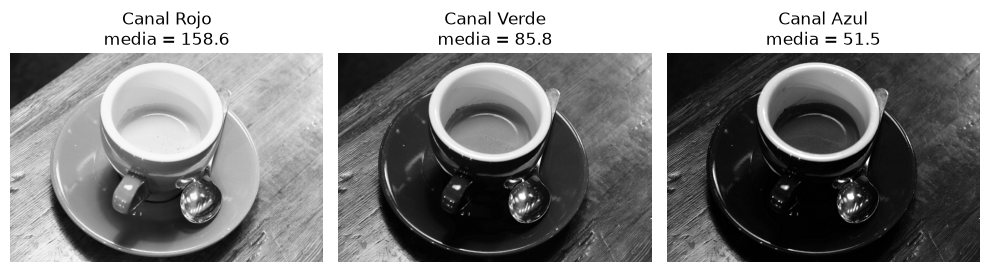


────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Cada imagen que ves es UN canal, mostrado en escala de grises: blanco
significa "mucha energía de ese color en ese punto", negro significa "poca".

Medias por canal -> Rojo: 158.6 | Verde: 85.8 | Azul: 51.5

El canal con la media más alta es el Rojo, y eso
te dice qué color domina la escena. Fíjate en la taza y en el líquido:
las zonas cálidas aparecen claras en el canal Rojo y oscuras en el Azul.

Conclusión operativa: elegir el canal adecuado ya es una forma de
extracción de características. Si tu problema consiste en detectar algo
rojo, quizá no necesites una red neuronal: basta con el canal correcto.


In [12]:
nombres = ["Rojo", "Verde", "Azul"]
fig, ejes = plt.subplots(1, 3)     # una fila, tres columnas de gráficos

for i in range(3):
    # img[:, :, i] = todas las filas, todas las columnas, solo el canal i
    canal = img[:, :, i]
    # cmap="gray" es obligatorio: sin él, matplotlib coloreaba el canal con su paleta por defecto
    ejes[i].imshow(canal, cmap="gray", vmin=0, vmax=255)
    ejes[i].set_title(f"Canal {nombres[i]}\nmedia = {canal.mean():.1f}")
    ejes[i].axis("off")

plt.tight_layout()
plt.show()

medias = [img[:, :, i].mean() for i in range(3)]

nota(f"""
    Cada imagen que ves es UN canal, mostrado en escala de grises: blanco
    significa "mucha energía de ese color en ese punto", negro significa "poca".

    Medias por canal -> Rojo: {medias[0]:.1f} | Verde: {medias[1]:.1f} | Azul: {medias[2]:.1f}

    El canal con la media más alta es el {nombres[int(np.argmax(medias))]}, y eso
    te dice qué color domina la escena. Fíjate en la taza y en el líquido:
    las zonas cálidas aparecen claras en el canal Rojo y oscuras en el Azul.

    Conclusión operativa: elegir el canal adecuado ya es una forma de
    extracción de características. Si tu problema consiste en detectar algo
    rojo, quizá no necesites una red neuronal: basta con el canal correcto.
""")

## 5. Escala de grises: el promedio ingenuo no es perceptual

Convertir a grises parece trivial: promediar los tres canales. Pero ese promedio supone que el ojo humano es igual de sensible al rojo, al verde y al azul, y no lo es.

Aquí comparamos dos fórmulas: el promedio aritmético y la luminancia ITU-R BT.601, que pondera cada canal según la sensibilidad real de la retina humana. Es la primera vez en el curso que un algoritmo incorpora un modelo del sensor biológico.

In [14]:
def a_gris_promedio(imagen):
    """Promedio aritmético simple de los tres canales."""
    # axis=2 promedia a lo largo del eje de los canales, dejando un arreglo 2D
    return imagen.mean(axis=2).astype(np.uint8)


def a_gris_luminancia(imagen):
    """Ponderación ITU-R BT.601, según la sensibilidad del ojo humano."""
    pesos = np.array([0.299, 0.587, 0.114])     # R, G, B -> suman 1.0
    # Broadcasting: los 3 pesos se aplican al último eje de la imagen (H,W,3)
    return (imagen * pesos).sum(axis=2).astype(np.uint8)


gris_prom = a_gris_promedio(img)
gris_lum = a_gris_luminancia(img)

# Convertimos a int con signo antes de restar: en uint8, 10 - 20 daría 246, no -10
diferencia = np.abs(gris_prom.astype(int) - gris_lum.astype(int))

print("Forma del resultado :", gris_lum.shape, "(ya no hay tercer eje)")
print("Diferencia media    :", round(diferencia.mean(), 2), "niveles")
print("Diferencia máxima   :", diferencia.max(), "niveles")

nota(f"""
    Ambas funciones devuelven un arreglo 2D de forma {gris_lum.shape}: el eje
    de los canales desapareció porque los tres colores se fundieron en uno.

    La diferencia entre los dos métodos es de {diferencia.mean():.2f} niveles en
    promedio, pero llega hasta {diferencia.max()} niveles en los puntos más
    críticos. No es despreciable: sobre un rango de 0 a 255, eso es un
    {100*diferencia.max()/255:.0f}% de error en las zonas peores.

    ¿Por qué los pesos 0.299 / 0.587 / 0.114? Porque la retina humana tiene
    aproximadamente el doble de sensibilidad al verde que al rojo, y unas seis
    veces más que al azul. La fórmula BT.601 reproduce esa respuesta.

    ATENCIÓN AL .astype(int) antes de restar: uint8 no admite negativos y
    "da la vuelta" (10 - 20 = 246). Es un error silencioso, no lanza excepción.
""")

Forma del resultado : (400, 600) (ya no hay tercer eje)
Diferencia media    : 5.1 niveles
Diferencia máxima   : 20 niveles

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Ambas funciones devuelven un arreglo 2D de forma (400, 600): el eje
de los canales desapareció porque los tres colores se fundieron en uno.

La diferencia entre los dos métodos es de 5.10 niveles en
promedio, pero llega hasta 20 niveles en los puntos más
críticos. No es despreciable: sobre un rango de 0 a 255, eso es un
8% de error en las zonas peores.

¿Por qué los pesos 0.299 / 0.587 / 0.114? Porque la retina humana tiene
aproximadamente el doble de sensibilidad al verde que al rojo, y unas seis
veces más que al azul. La fórmula BT.601 reproduce esa respuesta.

ATENCIÓN AL .astype(int) antes de restar: uint8 no admite negativos y
"da la vuelta" (10 - 20 = 246). Es un error silencioso, no la

## 6. Dónde importa la diferencia

Saber que el error promedio es de unos pocos niveles no dice en qué parte de la imagen ocurre. El mapa de diferencia absoluta lo responde: las zonas calientes son donde el método ingenuo falla.

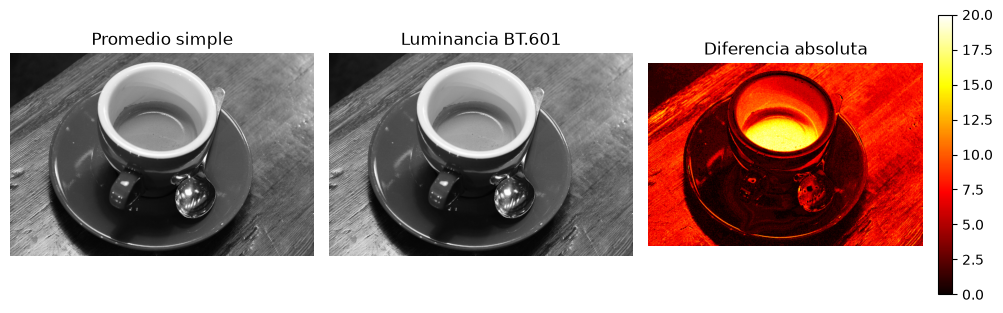


────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Las dos primeras imágenes se parecen a simple vista: por eso mucha gente
cree que da igual qué fórmula usar.

El tercer mapa desmiente esa impresión. Las zonas claras (amarillo) marcan
dónde ambos métodos discrepan más, y coinciden con las regiones de color
SATURADO, donde un canal domina fuertemente sobre los otros. En las zonas
grises o neutras, ambas fórmulas coinciden y el mapa está oscuro.

El 5.1% de los píxeles tiene una diferencia mayor a 10 niveles.

Lección: dos algoritmos pueden producir resultados casi idénticos "en
promedio" y diferir mucho en las regiones que justamente importan. Nunca
evalúes una transformación solo con una métrica global; mira dónde falla.


In [15]:
fig, ejes = plt.subplots(1, 3)

ejes[0].imshow(gris_prom, cmap="gray", vmin=0, vmax=255)
ejes[0].set_title("Promedio simple")

ejes[1].imshow(gris_lum, cmap="gray", vmin=0, vmax=255)
ejes[1].set_title("Luminancia BT.601")

# cmap="hot": negro = sin diferencia, amarillo/blanco = diferencia máxima
im = ejes[2].imshow(diferencia, cmap="hot")
ejes[2].set_title("Diferencia absoluta")
plt.colorbar(im, ax=ejes[2], fraction=0.046)    # escala de referencia del mapa

for e in ejes:
    e.axis("off")
plt.tight_layout()
plt.show()

# Porcentaje de píxeles cuya diferencia supera los 10 niveles
pct_afectado = 100 * (diferencia > 10).mean()

nota(f"""
    Las dos primeras imágenes se parecen a simple vista: por eso mucha gente
    cree que da igual qué fórmula usar.

    El tercer mapa desmiente esa impresión. Las zonas claras (amarillo) marcan
    dónde ambos métodos discrepan más, y coinciden con las regiones de color
    SATURADO, donde un canal domina fuertemente sobre los otros. En las zonas
    grises o neutras, ambas fórmulas coinciden y el mapa está oscuro.

    El {pct_afectado:.1f}% de los píxeles tiene una diferencia mayor a 10 niveles.

    Lección: dos algoritmos pueden producir resultados casi idénticos "en
    promedio" y diferir mucho en las regiones que justamente importan. Nunca
    evalúes una transformación solo con una métrica global; mira dónde falla.
""")

## 7. Resolución de cuantización (profundidad de bits)

Toda captura sensorial tiene dos resoluciones. La primera es la de cuantización: cuántos niveles distintos de intensidad puede distinguir el sensor. Con 8 bits son 256 niveles; con 4 bits, solo 16.

Aquí reducimos artificialmente esa resolución y observamos a partir de qué punto la imagen deja de ser reconocible. El resultado suele sorprender.

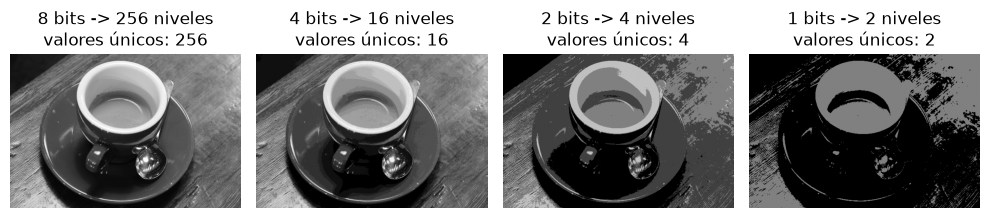


────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
De izquierda a derecha estamos empobreciendo el sensor.

Con 8 bits (256 niveles) la imagen es la original. Con 4 bits aparecen
bandas visibles en los degradados suaves: es el efecto llamado BANDING.
Con 2 bits solo quedan 4 tonos, y aun así el objeto SIGUE SIENDO
RECONOCIBLE.

Ese es el hallazgo importante de la celda: la información que te permite
reconocer un objeto no está distribuida por igual entre los bits. Los bits
más significativos cargan la forma; los menos significativos, el matiz.
Un sistema de percepción puede descartar los segundos sin perder la tarea.

Detalle técnico a observar: con 1 bit el blanco se ve GRIS, no blanco. Es
porque los dos niveles resultantes son 0 y 128, no 0 y 255. La cuantización
por división entera conserva el piso del escalón, no su techo.


In [16]:
def cuantizar(imagen, bits):
    """Reduce la imagen a 2**bits niveles de intensidad."""
    niveles = 2 ** bits
    paso = 256 // niveles          # ancho de cada escalón de intensidad
    # La división entera // "tira" el detalle fino; al multiplicar volvemos
    # al rango original, pero ya solo con los valores múltiplos de `paso`
    return (imagen // paso) * paso


fig, ejes = plt.subplots(1, 4)
for eje, b in zip(ejes, [8, 4, 2, 1]):
    q = cuantizar(gris_lum, b)
    # vmin/vmax fijos: sin esto matplotlib reescalaría cada imagen y ocultaría el efecto
    eje.imshow(q, cmap="gray", vmin=0, vmax=255)
    eje.set_title(f"{b} bits -> {2**b} niveles\nvalores únicos: {len(np.unique(q))}")
    eje.axis("off")

plt.tight_layout()
plt.show()

nota("""
    De izquierda a derecha estamos empobreciendo el sensor.

    Con 8 bits (256 niveles) la imagen es la original. Con 4 bits aparecen
    bandas visibles en los degradados suaves: es el efecto llamado BANDING.
    Con 2 bits solo quedan 4 tonos, y aun así el objeto SIGUE SIENDO
    RECONOCIBLE.

    Ese es el hallazgo importante de la celda: la información que te permite
    reconocer un objeto no está distribuida por igual entre los bits. Los bits
    más significativos cargan la forma; los menos significativos, el matiz.
    Un sistema de percepción puede descartar los segundos sin perder la tarea.

    Detalle técnico a observar: con 1 bit el blanco se ve GRIS, no blanco. Es
    porque los dos niveles resultantes son 0 y 128, no 0 y 255. La cuantización
    por división entera conserva el piso del escalón, no su techo.
""")

## 8. Resolución de muestreo espacial

La segunda resolución es la de muestreo: cada cuánto el sensor toma una medida del mundo. En una imagen equivale a cuántos píxeles por centímetro de escena.

Vamos a submuestrear tomando un píxel de cada N, sin ningún filtrado previo. Guarda bien lo que ocurre a factor alto: en la semana 2 verás por qué esto es un error, y en la semana 3 entenderás la razón matemática.

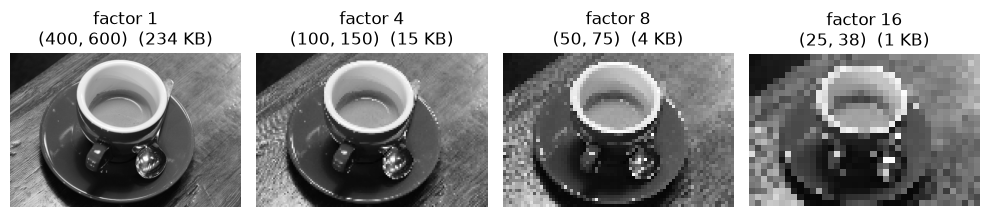


────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
El operador [::f] es submuestreo: conserva una fila de cada f y una
columna de cada f. Como actúa en los DOS ejes, el dato se reduce por f²:
a factor 16 pasamos de 234 KB a 0.9 KB, es decir
253 veces menos.

Observa los bordes y las texturas finas en las dos últimas imágenes. No
solo se ven "pixeladas": aparecen patrones y escalones que NO EXISTÍAN en
la imagen original. Eso no es pérdida de detalle, es información falsa
creada por el propio muestreo.

Ese fenómeno se llama ALIASING. En la celda 11 lo volverás a encontrar,
pero esta vez lo vas a ESCUCHAR en una señal de audio. Son el mismo
problema con distinto disfraz.


In [17]:
def submuestrear(imagen, factor):
    """Toma un píxel de cada `factor`, sin ningún filtrado previo."""
    # Slicing con paso: [inicio:fin:paso]. Omitir inicio y fin significa "todo"
    return imagen[::factor, ::factor]


fig, ejes = plt.subplots(1, 4)
for eje, f in zip(ejes, [1, 4, 8, 16]):
    sub = submuestrear(gris_lum, f)
    eje.imshow(sub, cmap="gray", vmin=0, vmax=255)
    eje.set_title(f"factor {f}\n{sub.shape}  ({sub.nbytes/1024:.0f} KB)")
    eje.axis("off")

plt.tight_layout()
plt.show()

orig = gris_lum.nbytes
red = submuestrear(gris_lum, 16).nbytes

nota(f"""
    El operador [::f] es submuestreo: conserva una fila de cada f y una
    columna de cada f. Como actúa en los DOS ejes, el dato se reduce por f²:
    a factor 16 pasamos de {orig/1024:.0f} KB a {red/1024:.1f} KB, es decir
    {orig/red:.0f} veces menos.

    Observa los bordes y las texturas finas en las dos últimas imágenes. No
    solo se ven "pixeladas": aparecen patrones y escalones que NO EXISTÍAN en
    la imagen original. Eso no es pérdida de detalle, es información falsa
    creada por el propio muestreo.

    Ese fenómeno se llama ALIASING. En la celda 11 lo volverás a encontrar,
    pero esta vez lo vas a ESCUCHAR en una señal de audio. Son el mismo
    problema con distinto disfraz.
""")

## 9. La misma idea, otra modalidad: el audio

Hasta aquí todo fue visual. Ahora cambiamos de sentido, pero no de estructura de datos: el audio también es un arreglo de NumPy.

La correspondencia es directa. Una imagen está muestreada en el espacio y es 2D; una señal de audio está muestreada en el tiempo y es 1D. La frecuencia de muestreo fs cumple para el audio el mismo papel que la resolución en píxeles para la imagen.

In [18]:
fs = 8000          # frecuencia de muestreo: 8000 medidas por segundo (Hz)
dur = 1.0          # duración en segundos
f0 = 440           # frecuencia del tono a generar (Hz) = nota LA

# linspace crea los instantes de tiempo en los que "medimos" la señal.
# endpoint=False evita repetir el instante final, que ya pertenece al ciclo siguiente
t = np.linspace(0, dur, int(fs * dur), endpoint=False)

# La onda senoidal: 2*pi*f0*t convierte tiempo en fase; 0.8 es la amplitud
senal = 0.8 * np.sin(2 * np.pi * f0 * t)

print("Forma        :", senal.shape)
print("Tipo de dato :", senal.dtype)
print("Rango        :", round(senal.min(), 2), "a", round(senal.max(), 2))
print("Muestras/s   :", fs)
print("Ciclos en 1 s:", f0)
print("Muestras por ciclo:", round(fs / f0, 1))

nota(f"""
    La señal es un arreglo de UNA dimensión con {senal.shape[0]} elementos:
    {fs} muestras por segundo durante {dur:.0f} segundo.

    Compara con la imagen de la celda 2:

      Imagen -> arreglo 2D, muestreado en el ESPACIO, dtype uint8, rango [0,255]
      Audio  -> arreglo 1D, muestreado en el TIEMPO,  dtype float64, rango [-1,1]

    Cambia la dimensión, el dominio y la convención de rango, pero la
    naturaleza del dato es idéntica: números en una grilla regular.

    El dato clave de esta celda son las {fs/f0:.1f} muestras por ciclo. Con
    tantas muestras la onda queda bien descrita. En la celda 11 bajaremos esa
    cifra y veremos qué pasa cuando ya no alcanzan.
""")

Forma        : (8000,)
Tipo de dato : float64
Rango        : -0.8 a 0.8
Muestras/s   : 8000
Ciclos en 1 s: 440
Muestras por ciclo: 18.2

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
La señal es un arreglo de UNA dimensión con 8000 elementos:
8000 muestras por segundo durante 1 segundo.

Compara con la imagen de la celda 2:

  Imagen -> arreglo 2D, muestreado en el ESPACIO, dtype uint8, rango [0,255]
  Audio  -> arreglo 1D, muestreado en el TIEMPO,  dtype float64, rango [-1,1]

Cambia la dimensión, el dominio y la convención de rango, pero la
naturaleza del dato es idéntica: números en una grilla regular.

El dato clave de esta celda son las 18.2 muestras por ciclo. Con
tantas muestras la onda queda bien descrita. En la celda 11 bajaremos esa
cifra y veremos qué pasa cuando ya no alcanzan.


## 10. Ver la señal a dos escalas

Cuando grafiques una señal completa parecerá una onda continua. Es una ilusión del trazado: matplotlib une los puntos con líneas rectas y tu ojo completa el resto.

Al hacer zoom sobre unas pocas muestras aparece la verdad: el dato son puntos discretos, no una curva.

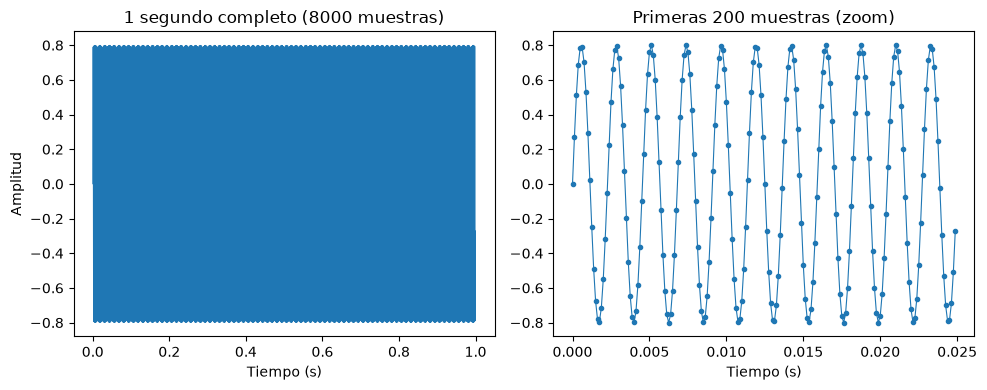


────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Izquierda: a esta escala se ven 440 ciclos comprimidos en el ancho del
gráfico. Parece una mancha sólida porque hay más ciclos que píxeles de
pantalla disponibles. Esto ES aliasing, ahora en el propio gráfico.

Derecha: al ampliar a 200 muestras aparece la forma senoidal, y cada
círculo es UNA muestra real. Entre círculo y círculo no hay dato: la línea
que los une la dibuja matplotlib, no existe en el arreglo.

Cuenta los círculos que caben en un ciclo completo: deberían ser unos
18, que es exactamente fs/f0. Esa cantidad es la que determina
si la señal está bien capturada o no.


In [19]:
fig, ejes = plt.subplots(1, 2)

ejes[0].plot(t, senal, linewidth=0.5)
ejes[0].set_title(f"1 segundo completo ({len(senal)} muestras)")
ejes[0].set_xlabel("Tiempo (s)")
ejes[0].set_ylabel("Amplitud")

# Solo las primeras 200 muestras, con marcador para ver cada punto individual
ejes[1].plot(t[:200], senal[:200], marker="o", markersize=3, linewidth=0.8)
ejes[1].set_title("Primeras 200 muestras (zoom)")
ejes[1].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

nota(f"""
    Izquierda: a esta escala se ven {f0} ciclos comprimidos en el ancho del
    gráfico. Parece una mancha sólida porque hay más ciclos que píxeles de
    pantalla disponibles. Esto ES aliasing, ahora en el propio gráfico.

    Derecha: al ampliar a 200 muestras aparece la forma senoidal, y cada
    círculo es UNA muestra real. Entre círculo y círculo no hay dato: la línea
    que los une la dibuja matplotlib, no existe en el arreglo.

    Cuenta los círculos que caben en un ciclo completo: deberían ser unos
    {fs/f0:.0f}, que es exactamente fs/f0. Esa cantidad es la que determina
    si la señal está bien capturada o no.
""")

## 11. Aliasing: el mismo fenómeno de la celda 8, ahora audible

Esta celda cierra la sesión. Vamos a generar el mismo tono de 440 Hz a distintas frecuencias de muestreo y a escucharlo.

El teorema de Nyquist dice que para capturar correctamente una señal hay que muestrearla a más del doble de su frecuencia máxima. La mitad de fs se llama frecuencia de Nyquist y es el techo de lo representable. Por debajo de ese límite, la señal no se pierde: se transforma en otra cosa.

In [22]:
from IPython.display import Audio, display
from scipy.signal import resample

FS_REPRODUCCION = 44100    # fija para todos: es la que entiende el navegador

print(f"Tono original: {f0} Hz\n")

for fs_captura in [8000, 1000, 800, 500]:
    # 1. CAPTURA a la frecuencia baja: aquí es donde ocurre (o no) el aliasing
    t_c = np.linspace(0, dur, int(fs_captura * dur), endpoint=False)
    s_c = 0.8 * np.sin(2 * np.pi * f0 * t_c)

    nyquist = fs_captura / 2                  # techo de lo representable
    hay_alias = f0 >= nyquist
    # Si hay aliasing, la frecuencia se "refleja" sobre Nyquist
    percibida = abs(f0 - fs_captura) if hay_alias else f0

    # 2. RECONSTRUCCIÓN a 44100 Hz solo para poder reproducir.
    #    resample usa interpolación sinc: no agrega ni quita frecuencias,
    #    solo rellena entre las muestras ya capturadas.
    s_play = resample(s_c, int(FS_REPRODUCCION * dur))

    print(f"fs captura = {fs_captura:5d} Hz | Nyquist = {nyquist:6.0f} Hz | "
          f"muestras/ciclo = {fs_captura/f0:5.2f} | se oirá ~{percibida:3.0f} Hz | "
          f"{'ALIASING' if hay_alias else 'OK'}")
    display(Audio(s_play, rate=FS_REPRODUCCION))

nota("""
    Escucha los cuatro audios en orden. Los dos primeros suenan igual: el tono
    de 440 Hz está por debajo de su frecuencia de Nyquist y se representa bien.

    Con fs = 800 Hz el límite de Nyquist es 400 Hz, por debajo de los 440 Hz
    del tono. El resultado no es un sonido degradado ni con ruido: es un tono
    DISTINTO, más grave (unos 360 Hz). La señal no se perdió, se transformó en
    otra que el sistema no puede distinguir de la original. De ahí el nombre
    "alias".

    Esto es exactamente lo mismo que viste en la celda 8: al submuestrear la
    imagen sin filtrar, las texturas finas no desaparecieron, se convirtieron
    en patrones falsos.

    REGLA PRÁCTICA para todo el curso: antes de reducir la resolución de
    cualquier señal, hay que eliminar primero las componentes que la nueva
    resolución no puede representar. Ese filtrado previo es el tema de la
    semana 2, y la herramienta para ver esas componentes es la transformada
    de Fourier, tema de la semana 3.
""")

Tono original: 440 Hz

fs captura =  8000 Hz | Nyquist =   4000 Hz | muestras/ciclo = 18.18 | se oirá ~440 Hz | OK


fs captura =  1000 Hz | Nyquist =    500 Hz | muestras/ciclo =  2.27 | se oirá ~440 Hz | OK


fs captura =   800 Hz | Nyquist =    400 Hz | muestras/ciclo =  1.82 | se oirá ~360 Hz | ALIASING


fs captura =   500 Hz | Nyquist =    250 Hz | muestras/ciclo =  1.14 | se oirá ~ 60 Hz | ALIASING



────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
Escucha los cuatro audios en orden. Los dos primeros suenan igual: el tono
de 440 Hz está por debajo de su frecuencia de Nyquist y se representa bien.

Con fs = 800 Hz el límite de Nyquist es 400 Hz, por debajo de los 440 Hz
del tono. El resultado no es un sonido degradado ni con ruido: es un tono
DISTINTO, más grave (unos 360 Hz). La señal no se perdió, se transformó en
otra que el sistema no puede distinguir de la original. De ahí el nombre
"alias".

Esto es exactamente lo mismo que viste en la celda 8: al submuestrear la
imagen sin filtrar, las texturas finas no desaparecieron, se convirtieron
en patrones falsos.

REGLA PRÁCTICA para todo el curso: antes de reducir la resolución de
cualquier señal, hay que eliminar primero las componentes que la nueva
resolución no puede representar. Ese filtrado previo es el 

## 12. Una sola ficha para cualquier modalidad

Cerramos con la evidencia de la idea rectora de la clase: si imagen y audio son el mismo tipo de objeto, una sola función debe poder describir a los dos.

Esta función es además la base de la tarea de esta semana, donde la extenderás para trabajar con tus propios datos capturados.

In [21]:
def describir(arreglo, nombre="dato"):
    """Imprime la ficha básica de cualquier dato sensorial."""
    print(f"--- {nombre} ---")
    print(f"  dimensiones : {arreglo.ndim}")
    print(f"  forma       : {arreglo.shape}")
    print(f"  tipo        : {arreglo.dtype}")
    # :.3f fuerza 3 decimales; funciona igual con enteros y con flotantes
    print(f"  rango       : [{arreglo.min():.3f}, {arreglo.max():.3f}]")
    print(f"  media       : {arreglo.mean():.3f}")
    print(f"  memoria     : {arreglo.nbytes / 1024:.1f} KB")


describir(img, "Imagen RGB")
describir(gris_lum, "Imagen en grises")
describir(senal, "Señal de audio")

nota("""
    La misma función describió las tres cosas sin una sola línea condicional.
    Eso es posible porque las tres son arreglos de NumPy y exponen los mismos
    atributos: ndim, shape, dtype, min, max, mean, nbytes.

    Ese es el resumen de la clase: en percepción computacional la modalidad
    (visual, acústica, táctil, térmica) cambia el SIGNIFICADO de los números,
    pero no su ESTRUCTURA. Por eso las mismas técnicas, filtrado, transformada
    de Fourier, extracción de características, se aplican a todas.

    Compara las tres fichas y responde antes de la próxima sesión:
    ¿por qué el audio es float64 con rango [-1, 1] mientras la imagen es uint8
    con rango [0, 255]? ¿Qué convención hay detrás de cada elección?
""")

--- Imagen RGB ---
  dimensiones : 3
  forma       : (400, 600, 3)
  tipo        : uint8
  rango       : [0.000, 255.000]
  media       : 98.616
  memoria     : 703.1 KB
--- Imagen en grises ---
  dimensiones : 2
  forma       : (400, 600)
  tipo        : uint8
  rango       : [0.000, 255.000]
  media       : 103.134
  memoria     : 234.4 KB
--- Señal de audio ---
  dimensiones : 1
  forma       : (8000,)
  tipo        : float64
  rango       : [-0.800, 0.800]
  media       : 0.000
  memoria     : 62.5 KB

────────────────────────────────────────────────────────────────────────
QUÉ SIGNIFICA ESTE RESULTADO
────────────────────────────────────────────────────────────────────────
La misma función describió las tres cosas sin una sola línea condicional.
Eso es posible porque las tres son arreglos de NumPy y exponen los mismos
atributos: ndim, shape, dtype, min, max, mean, nbytes.

Ese es el resumen de la clase: en percepción computacional la modalidad
(visual, acústica, táctil, térmica) c

## 13. Glosario de la sesión

Durante la clase aparecieron términos técnicos que quizá escuchaste por primera vez. Esta celda los reúne y explica brevemente. No es material adicional: es el vocabulario mínimo para entender lo que hicimos y para poder leer documentación técnica por tu cuenta.

Ejecútala cuando repases. Los términos marcados con 🔜 se retomarán en semanas posteriores.

In [23]:
GLOSARIO = {

    # ─────────── Representación del dato ───────────
    "Dato sensorial": (
        "Medida numérica que un sensor toma del mundo físico. Una imagen mide luz, "
        "un audio mide presión del aire, un acelerómetro mide movimiento. En todos "
        "los casos el resultado es un arreglo de números en una grilla regular."
    ),
    "uint8 / float64": (
        "Tipos de dato de NumPy. 'uint8' = entero sin signo de 8 bits, 256 valores "
        "posibles (0 a 255), usado en imágenes. 'float64' = decimal de 64 bits, gran "
        "precisión y admite negativos, usado en audio. El tipo define qué valores "
        "caben y cuánta memoria ocupa cada número."
    ),
    "Canal": (
        "Cada una de las capas de una imagen a color. Una imagen RGB tiene 3 canales "
        "y cada uno es una imagen en grises que mide cuánta luz roja, verde o azul "
        "llegó a cada punto del sensor."
    ),
    "Correlación espacial": (
        "Propiedad por la cual los píxeles vecinos tienen valores parecidos, porque "
        "el mundo real está hecho de superficies continuas y no de ruido. Es la razón "
        "de que las imágenes se puedan comprimir y filtrar."
    ),

    # ─────────── Percepción y color ───────────
    "Luminancia (y luma)": (
        "Medida de qué tan clara se percibe una zona, combinando los tres canales de "
        "color. No es el promedio simple: pondera cada canal según la sensibilidad "
        "real del ojo humano. Estrictamente lo que calculamos se llama 'luma' (Y'), "
        "porque opera sobre valores con gamma; la luminancia (Y) exige linealizar primero."
    ),
    "ITU-R BT.601": (
        "Estándar internacional de la Unión Internacional de Telecomunicaciones "
        "(sector Radiocomunicaciones, serie Broadcasting-Television, recomendación 601), "
        "publicado en 1982 para digitalizar televisión. De él tomamos la fórmula "
        "Y = 0.299R + 0.587G + 0.114B. Los pesos derivan de la curva de sensibilidad "
        "del ojo: el verde pesa el doble que el rojo y seis veces más que el azul. "
        "OJO: existen variantes más nuevas (BT.709 para HD, BT.2020 para UHD) con "
        "pesos distintos, y las librerías no usan todas el mismo estándar."
    ),
    "Corrección gamma": (
        "Transformación no lineal que se aplica a las imágenes al guardarlas, porque "
        "la percepción humana del brillo tampoco es lineal. Por eso el valor 128 no "
        "se ve como 'la mitad de brillante' que el 255. 🔜 Semana 2."
    ),

    # ─────────── Resolución y muestreo ───────────
    "Cuantización": (
        "Discretización del EJE DE AMPLITUD: cuántos niveles distintos de intensidad "
        "puede distinguir el sensor. Con 8 bits son 256 niveles; con 4 bits, 16. "
        "Reducirla produce 'banding' (bandas visibles en los degradados)."
    ),
    "Muestreo": (
        "Discretización del EJE DEL DOMINIO: cada cuánto se toma una medida. En una "
        "imagen es cada cuántos milímetros de escena hay un píxel; en audio, cuántas "
        "medidas por segundo. Es la otra mitad de la digitalización, junto a la cuantización."
    ),
    "Frecuencia de muestreo (fs)": (
        "Número de muestras tomadas por segundo, en hercios (Hz). El audio de CD usa "
        "44,100 Hz; la telefonía, 8,000 Hz. Cuanto mayor, más fiel es la captura y más "
        "pesa el archivo."
    ),
    "Frecuencia de Nyquist": (
        "La mitad de la frecuencia de muestreo (fs/2). Es el techo de lo representable: "
        "ninguna frecuencia por encima de ese límite puede capturarse correctamente. "
        "El teorema de Nyquist-Shannon dice que hay que muestrear a MÁS DEL DOBLE de la "
        "frecuencia máxima presente en la señal."
    ),
    "Aliasing": (
        "Lo que ocurre al muestrear por debajo del límite de Nyquist: la señal no se "
        "pierde ni se degrada, se CONVIERTE en otra distinta e indistinguible de una "
        "señal legítima. De ahí el nombre 'alias'. En audio es un tono equivocado; en "
        "imagen son patrones o escalones falsos en bordes y texturas."
    ),
    "Reconstrucción / resample": (
        "Proceso de generar muestras a una frecuencia distinta a partir de las ya "
        "capturadas, interpolando entre ellas. Es lo que hace un convertidor digital-"
        "analógico al reproducir. Importante: reconstruir NO repara el aliasing, porque "
        "el alias ya quedó grabado en las muestras al momento de capturar."
    ),

    # ─────────── Herramientas ───────────
    "Broadcasting (NumPy)": (
        "Mecanismo por el que NumPy aplica una operación entre arreglos de formas "
        "distintas sin escribir bucles. Es lo que permite multiplicar una imagen "
        "(alto, ancho, 3) por un vector de 3 pesos: NumPy alinea el último eje solo."
    ),
    "Slicing con paso": (
        "La sintaxis arreglo[inicio:fin:paso]. Omitir inicio y fin significa 'todo'. "
        "Por eso img[::4, ::4] conserva una fila y una columna de cada cuatro: es "
        "submuestreo escrito en una línea."
    ),
}


def mostrar_glosario(diccionario, ancho=76):
    """Imprime el glosario con el texto ajustado al ancho indicado."""
    print("=" * ancho)
    print("GLOSARIO — SEMANA 1: ANATOMÍA DEL DATO SENSORIAL".center(ancho))
    print("=" * ancho)
    for termino, definicion in diccionario.items():
        print(f"\n▸ {termino.upper()}")
        # textwrap.fill corta el texto en líneas del ancho dado sin partir palabras
        print(textwrap.fill(definicion, width=ancho - 4,
                            initial_indent="  ", subsequent_indent="  "))
    print("\n" + "=" * ancho)
    print(f"{len(diccionario)} términos. Los marcados 🔜 se retoman en semanas siguientes.")
    print("=" * ancho)


mostrar_glosario(GLOSARIO)

              GLOSARIO — SEMANA 1: ANATOMÍA DEL DATO SENSORIAL              

▸ DATO SENSORIAL
  Medida numérica que un sensor toma del mundo físico. Una imagen mide
  luz, un audio mide presión del aire, un acelerómetro mide movimiento.
  En todos los casos el resultado es un arreglo de números en una grilla
  regular.

▸ UINT8 / FLOAT64
  Tipos de dato de NumPy. 'uint8' = entero sin signo de 8 bits, 256
  valores posibles (0 a 255), usado en imágenes. 'float64' = decimal de
  64 bits, gran precisión y admite negativos, usado en audio. El tipo
  define qué valores caben y cuánta memoria ocupa cada número.

▸ CANAL
  Cada una de las capas de una imagen a color. Una imagen RGB tiene 3
  canales y cada uno es una imagen en grises que mide cuánta luz roja,
  verde o azul llegó a cada punto del sensor.

▸ CORRELACIÓN ESPACIAL
  Propiedad por la cual los píxeles vecinos tienen valores parecidos,
  porque el mundo real está hecho de superficies continuas y no de
  ruido. Es la razón de que l

In [25]:
def buscar(palabra):
    """Busca un término en el glosario, sin distinguir mayúsculas ni acentos exactos."""
    encontrados = {k: v for k, v in GLOSARIO.items()
                   if palabra.lower() in k.lower()}
    if not encontrados:
        print(f"No se encontró '{palabra}'. Términos disponibles:")
        print("  " + " | ".join(GLOSARIO.keys()))
        return
    mostrar_glosario(encontrados)


buscar("ITU-R BT.601")

              GLOSARIO — SEMANA 1: ANATOMÍA DEL DATO SENSORIAL              

▸ ITU-R BT.601
  Estándar internacional de la Unión Internacional de Telecomunicaciones
  (sector Radiocomunicaciones, serie Broadcasting-Television,
  recomendación 601), publicado en 1982 para digitalizar televisión. De
  él tomamos la fórmula Y = 0.299R + 0.587G + 0.114B. Los pesos derivan
  de la curva de sensibilidad del ojo: el verde pesa el doble que el
  rojo y seis veces más que el azul. OJO: existen variantes más nuevas
  (BT.709 para HD, BT.2020 para UHD) con pesos distintos, y las
  librerías no usan todas el mismo estándar.

1 términos. Los marcados 🔜 se retoman en semanas siguientes.
